# 1. Introduzione e Data Cleaning
In questa prima fase carichiamo il dataset e procediamo con la pulizia dei dati. 
Dall'esplorazione iniziale notiamo che il dataset è **fortemente sbilanciato**: solo il 3.2% delle aziende risulta in bancarotta. Inoltre, non sono presenti valori nulli.

**Scelte progettuali:**
1. **Rimozione variabili costanti:** La colonna `Net Income Flag` presenta un solo valore per tutte le righe (deviazione standard pari a 0). Essendo inutile ai fini predittivi, viene eliminata.
2. **Gestione degli Outlier (Capping):** Per gestire i valori anomali (outlier), calcoliamo lo Z-score. Invece di rimuovere le righe che superano le 3 deviazioni standard (che comporterebbe la perdita di quasi metà dei rari casi di bancarotta), optiamo per il **Capping** (o Winsorization). I valori estremi vengono limitati al valore del *bound* (media $\pm$ 3 sigma). Questo ci permette di mitigare gli estremi preservando la preziosa classe minoritaria.
3. **Standardizzazione:** Utilizziamo lo `StandardScaler` per avere media 0 e varianza 1, passaggio fondamentale per i modelli basati sulle distanze (PCA, K-Means, SVM) e per la convergenza della Regressione Logistica.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('./data/data.csv', delimiter=',')

print(f"Dimensioni del dataset: {df.shape}")
print(f"Valori nulli totali: {df.isnull().sum().sum()}")
print(f"Distribuzione della variabile Target (Bankrupt?):\n{df['Bankrupt?'].value_counts(normalize=True)*100}")

Dimensioni del dataset: (6819, 96)
Valori nulli totali: 0
Distribuzione della variabile Target (Bankrupt?):
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


In [12]:
# 1. Rimozione colonne costanti
print("Drop della colonna costante ' Net Income Flag'")
df_clean = df.drop(columns=[' Net Income Flag'])

# Separiamo le features (X) dal target (y)
X = df_clean.drop(columns=['Bankrupt?'])
y = df_clean['Bankrupt?']

# 2. Gestione degli Outlier (Capping a 3 deviazioni standard)
# Sostituiamo i valori oltre 3 sigma con il valore limite stesso
X_capped = X.copy()
for col in X.columns:
    mean = X[col].mean()
    std = X[col].std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    # 'clip' limita i valori tra il bound inferiore e superiore
    X_capped[col] = np.clip(X[col], lower_bound, upper_bound)

print(f"Dimensioni X dopo il capping degli outlier: {X_capped.shape}")
print(f"Numero di fallimenti salvati: {y.sum()}")

# 3. Standardizzazione dei dati (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_capped)

# Trasformiamo l'array numpy di nuovo in un DataFrame per comodità futura
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("\nDati standardizzati con successo. Pronti per l'Analisi Esplorativa!")

Drop della colonna costante ' Net Income Flag'
Dimensioni X dopo il capping degli outlier: (6819, 94)
Numero di fallimenti salvati: 220

Dati standardizzati con successo. Pronti per l'Analisi Esplorativa!


# 2. Analisi Esplorativa (EDA) e PCA
L'obiettivo di questa fase è comprendere quali variabili guidano principalmente il rischio di bancarotta e visualizzare la struttura generale dei dati.

**Scelte progettuali:**
1. **Analisi delle Correlazioni:** Essendo presenti 94 variabili, un *pairplot* completo risulterebbe illeggibile. Calcoliamo la correlazione di Pearson rispetto al Target ed estraiamo le Top 5 correlazioni positive (driver di rischio, es. indebitamento) e le Top 5 negative (indicatori di salute, es. margini di profitto).
2. **Principal Component Analysis (PCA):** Utilizziamo la PCA per ridurre la dimensionalità. Lo *Scree Plot* ci permette di visualizzare quante componenti sono necessarie per spiegare buona parte della varianza (es. 80-90%). Successivamente proiettiamo i dati sulle prime due componenti (PC1 e PC2) per ottenere una visualizzazione 2D del nostro spazio multidimensionale.

In [13]:
import seaborn as sns

# Aggiungiamo temporaneamente il Target al dataframe scalato per calcolare le correlazioni
df_eda = X_scaled_df.copy()
df_eda['Bankrupt?'] = y.values

# Calcoliamo la correlazione di Pearson con la variabile Target
correlations = df_eda.corr()['Bankrupt?'].drop('Bankrupt?')

print("Top 5 variabili che AUMENTANO il rischio di bancarotta (Correlazione Positiva):")
print(correlations.sort_values(ascending=False).head(5))

print("\nTop 5 indicatori di SALUTE FINANZIARIA (Correlazione Negativa):")
print(correlations.sort_values(ascending=True).head(5))

Top 5 variabili che AUMENTANO il rischio di bancarotta (Correlazione Positiva):
Borrowing dependency                   0.278407
Debt ratio %                           0.248615
Current Liability to Current Assets    0.247321
Liability to Equity                    0.244006
Current Liabilities/Equity             0.215972
Name: Bankrupt?, dtype: float64

Top 5 indicatori di SALUTE FINANZIARIA (Correlazione Negativa):
Net Income to Stockholder's Equity                  -0.299770
Net Income to Total Assets                          -0.293493
Retained Earnings to Total Assets                   -0.280250
ROA(A) before interest and % after tax              -0.261293
ROA(B) before interest and depreciation after tax   -0.258527
Name: Bankrupt?, dtype: float64


Componenti per spiegare l'80% della varianza: 32
Componenti per spiegare il 90% della varianza: 43


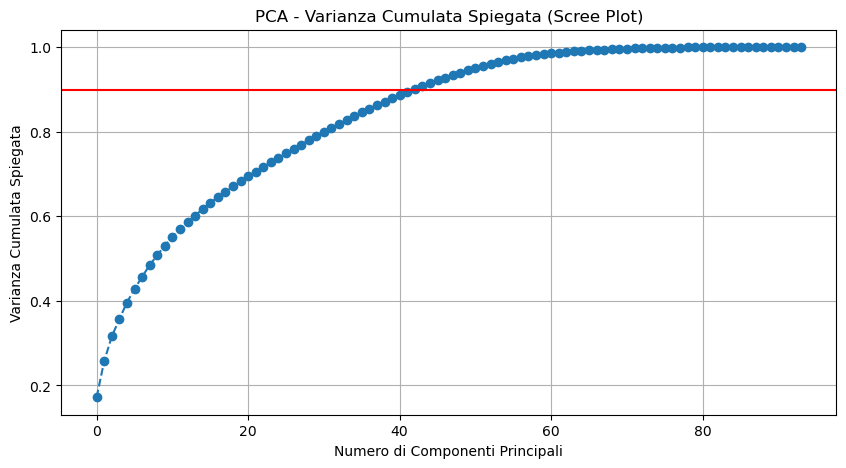

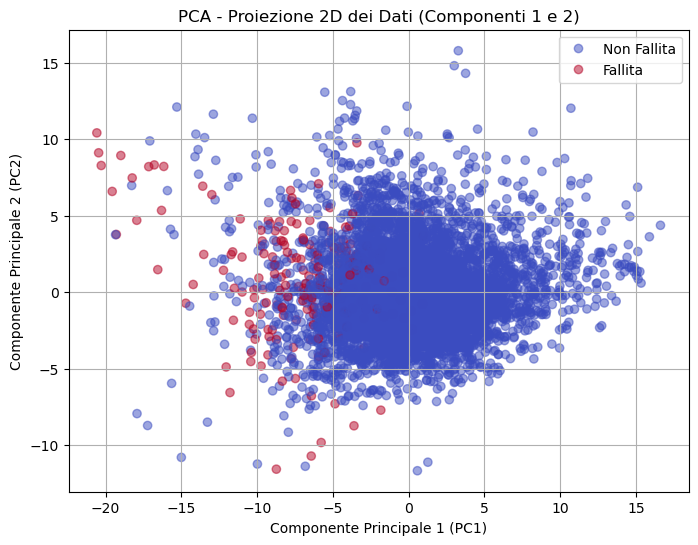

In [14]:
from sklearn.decomposition import PCA

# 1. Calcolo della PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled_df)

# Calcolo della varianza cumulata spiegata
var_ratio_cumulata = np.cumsum(pca.explained_variance_ratio_)

# Stampiamo quanti componenti servono per spiegare l'80% e il 90% della varianza
print(f"Componenti per spiegare l'80% della varianza: {np.argmax(var_ratio_cumulata >= 0.8) + 1}")
print(f"Componenti per spiegare il 90% della varianza: {np.argmax(var_ratio_cumulata >= 0.9) + 1}")

# 2. Plot del grafico Scree Plot (come fatto dal professore)
plt.figure(figsize=(10, 5))
plt.plot(var_ratio_cumulata, marker='o', linestyle='--')
plt.title('PCA - Varianza Cumulata Spiegata (Scree Plot)')
plt.xlabel('Numero di Componenti Principali')
plt.ylabel('Varianza Cumulata Spiegata')
plt.axhline(y=0.9, color='r', linestyle='-') # Linea rossa al 90%
plt.grid(True)
plt.show()

# 3. Plot dei dati proiettati sulle prime due Componenti Principali (PC1 e PC2)
plt.figure(figsize=(8, 6))
# Usiamo c=y per colorare i punti in base alla bancarotta (0 o 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.5)
plt.title('PCA - Proiezione 2D dei Dati (Componenti 1 e 2)')
plt.xlabel('Componente Principale 1 (PC1)')
plt.ylabel('Componente Principale 2 (PC2)')
plt.legend(handles=scatter.legend_elements()[0], labels=['Non Fallita', 'Fallita'])
plt.grid(True)
plt.show()

# 3. Modelli di Classificazione (Supervised Learning)
Trattandosi di un problema di classificazione binaria con un **fortissimo sbilanciamento delle classi** (96.8% vs 3.2%), l' *Accuracy* classica non è una metrica affidabile (un modello che prevede sempre "Sana" avrebbe il 96.8% di Accuracy ma sarebbe inutile).

**Scelte progettuali:**
1. **Metriche di Valutazione:** Ci focalizzeremo su alcune delle metriche principali (...).
2. **Bilanciamento:** Tramite SMOTE.
3. **Modelli Confrontati:**
   - *Logistic Regression:* Come baseline lineare.
   - *Decision Tree:* Ottimizzato tramite `GridSearchCV` per trovare il miglior iperparametro di pruning (`ccp_alpha`) ed evitare overfitting.
   - *Support Vector Machine (SVC):* Per catturare eventuali relazioni non lineari.
   - *Neural Networks*

In [24]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Distribuzione Target PRIMA dello SMOTE (Training Set):")
print(y_train.value_counts())
print("\nDistribuzione Target DOPO lo SMOTE (Training Set):")
print(y_train_smote.value_counts())
print("-" * 50)

def print_metrics(model_name, y_true, y_pred):
    print(f"\n--- Risultati per {model_name} ---")
    print(f"Accuracy:          {accuracy_score(y_true, y_pred):.3f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred):.3f}")
    print(f"Recall:            {recall_score(y_true, y_pred):.3f}")
    print(f"Precision:         {precision_score(y_true, y_pred):.3f}")
    print(f"F1-Score:          {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC:           {roc_auc_score(y_true, y_pred):.3f}")

Distribuzione Target PRIMA dello SMOTE (Training Set):
Bankrupt?
0    5279
1     176
Name: count, dtype: int64

Distribuzione Target DOPO lo SMOTE (Training Set):
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64
--------------------------------------------------


In [29]:
logreg_base = LogisticRegression(max_iter=1000, random_state=42)
logreg_base.fit(X_train, y_train)
y_pred_log_base = logreg_base.predict(X_test)
print_metrics("Logistic Regression (Dataset Sbilanciato, NO SMOTE)", y_test, y_pred_log_base)

logreg_smote = LogisticRegression(max_iter=1000, random_state=42)
logreg_smote.fit(X_train_smote, y_train_smote)
y_pred_log_smote = logreg_smote.predict(X_test)
print_metrics("Logistic Regression (CON SMOTE)", y_test, y_pred_log_smote)


--- Risultati per Logistic Regression (Dataset Sbilanciato, NO SMOTE) ---
Accuracy:          0.966
Balanced Accuracy: 0.609
Recall:            0.227
Precision:         0.435
F1-Score:          0.299
ROC-AUC:           0.609

--- Risultati per Logistic Regression (CON SMOTE) ---
Accuracy:          0.877
Balanced Accuracy: 0.827
Recall:            0.773
Precision:         0.177
F1-Score:          0.288
ROC-AUC:           0.827


In [30]:
grid_of_values = {'ccp_alpha': [0.1, 0.01, 0.001, 0.0001]}
grid_model_base = GridSearchCV(estimator=DecisionTreeClassifier(criterion='entropy', random_state=42), 
                               param_grid=grid_of_values, cv=5)
grid_model_base.fit(X_train, y_train)
best_alpha_base = grid_model_base.best_params_['ccp_alpha']

tree_base = DecisionTreeClassifier(criterion='entropy', ccp_alpha=best_alpha_base, random_state=42)
tree_base.fit(X_train, y_train)
y_pred_tree_base = tree_base.predict(X_test)
print(f"\nMiglior ccp_alpha trovato (NO SMOTE): {best_alpha_base}")
print_metrics("Decision Tree (Dataset Sbilanciato, NO SMOTE)", y_test, y_pred_tree_base)


grid_model_smote = GridSearchCV(estimator=DecisionTreeClassifier(criterion='entropy', random_state=42), 
                                param_grid=grid_of_values, cv=5)
grid_model_smote.fit(X_train_smote, y_train_smote)
best_alpha_smote = grid_model_smote.best_params_['ccp_alpha']

tree_smote = DecisionTreeClassifier(criterion='entropy', ccp_alpha=best_alpha_smote, random_state=42)
tree_smote.fit(X_train_smote, y_train_smote)
y_pred_tree_smote = tree_smote.predict(X_test)
print(f"\nMiglior ccp_alpha trovato (CON SMOTE): {best_alpha_smote}")
print_metrics("Decision Tree (CON SMOTE)", y_test, y_pred_tree_smote)


Miglior ccp_alpha trovato (NO SMOTE): 0.1

--- Risultati per Decision Tree (Dataset Sbilanciato, NO SMOTE) ---
Accuracy:          0.968
Balanced Accuracy: 0.500
Recall:            0.000
Precision:         0.000
F1-Score:          0.000
ROC-AUC:           0.500


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Miglior ccp_alpha trovato (CON SMOTE): 0.0001

--- Risultati per Decision Tree (CON SMOTE) ---
Accuracy:          0.938
Balanced Accuracy: 0.759
Recall:            0.568
Precision:         0.275
F1-Score:          0.370
ROC-AUC:           0.759


In [31]:
svm_base = SVC(probability=True, random_state=42)
svm_base.fit(X_train, y_train)
y_pred_svm_base = svm_base.predict(X_test)
print_metrics("Support Vector Machine (Dataset Sbilanciato, NO SMOTE)", y_test, y_pred_svm_base)

svm_smote = SVC(probability=True, random_state=42)
svm_smote.fit(X_train_smote, y_train_smote)
y_pred_svm_smote = svm_smote.predict(X_test)
print_metrics("Support Vector Machine (CON SMOTE)", y_test, y_pred_svm_smote)


--- Risultati per Support Vector Machine (Dataset Sbilanciato, NO SMOTE) ---
Accuracy:          0.968
Balanced Accuracy: 0.500
Recall:            0.000
Precision:         0.000
F1-Score:          0.000
ROC-AUC:           0.500


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



--- Risultati per Support Vector Machine (CON SMOTE) ---
Accuracy:          0.912
Balanced Accuracy: 0.746
Recall:            0.568
Precision:         0.198
F1-Score:          0.294
ROC-AUC:           0.746


In [33]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

mlp_base = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp_base.fit(X_train, y_train)
y_pred_mlp_base = mlp_base.predict(X_test)
print_metrics("Neural Network (Dataset Sbilanciato, NO SMOTE)", y_test, y_pred_mlp_base)

mlp_smote = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp_smote.fit(X_train_smote, y_train_smote)
y_pred_mlp_smote = mlp_smote.predict(X_test)
print_metrics("Neural Network (CON SMOTE)", y_test, y_pred_mlp_smote)


--- Risultati per Neural Network (Dataset Sbilanciato, NO SMOTE) ---
Accuracy:          0.961
Balanced Accuracy: 0.639
Recall:            0.295
Precision:         0.371
F1-Score:          0.329
ROC-AUC:           0.639

--- Risultati per Neural Network (CON SMOTE) ---
Accuracy:          0.957
Balanced Accuracy: 0.681
Recall:            0.386
Precision:         0.354
F1-Score:          0.370
ROC-AUC:           0.681


# 4. Segmentazione delle Aziende (Unsupervised Learning)
Come ultimo step, vogliamo capire se esistono dei "profili" naturali tra le aziende analizzate, a prescindere dall'etichetta di bancarotta. 

**Scelte progettuali:**
1. **Algoritmo K-Means:** Utilizziamo il clustering K-Means sui dati scalati.
2. **Scelta di K:** Per determinare il numero ottimale di cluster non andiamo a tentativi, ma calcoliamo il **Silhouette Score** per diversi valori di K, scegliendo quello che massimizza la separazione e coesione dei gruppi.
3. **Analisi del Rischio:** Proiettiamo i cluster trovati nello spazio PCA per visualizzarli e, infine, eseguiamo una *cross-tabulation* per vedere la distribuzione delle bancarotte nei cluster trovati. L'obiettivo è verificare se l'algoritmo non supervisionato è riuscito a isolare un cluster "ad alto rischio".

Calcolo del Silhouette Score per diversi valori di K...
Per K=2, il Silhouette score è: 0.104
Per K=3, il Silhouette score è: 0.108
Per K=4, il Silhouette score è: 0.086
Per K=5, il Silhouette score è: 0.061

Il K ottimale è 3. Addestriamo il K-Means finale...


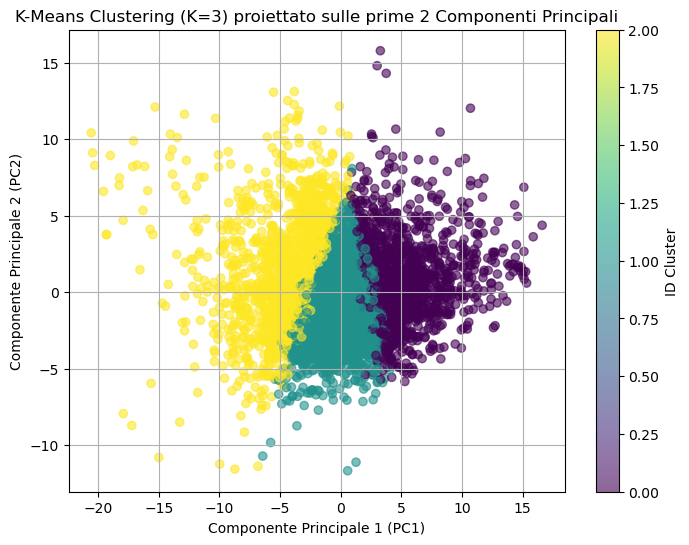


Distribuzione delle bancarotte nei cluster:
Bankrupt?        0.0        1.0
Cluster                        
0          99.928927   0.071073
1          99.356002   0.643998
2          87.320261  12.679739


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Ricerca del K ottimale tramite Silhouette Score
print("Calcolo del Silhouette Score per diversi valori di K...")
silhouette_scores = []
K_range = range(2, 6) # Testiamo da 2 a 5 cluster

for k in K_range:
    # n_init='auto' previene warning nelle nuove versioni di sklearn
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_scaled_df)
    silhouette_avg = silhouette_score(X_scaled_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Per K={k}, il Silhouette score è: {silhouette_avg:.3f}")

# 2. Addestramento col K migliore
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nIl K ottimale è {best_k}. Addestriamo il K-Means finale...")

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
clusters = kmeans_final.fit_predict(X_scaled_df)

# 3. Visualizzazione dei cluster usando la PCA (PC1 e PC2)
plt.figure(figsize=(8, 6))
# Usiamo X_pca (che avevi già calcolato nel blocco dell'Analisi Esplorativa)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title(f'K-Means Clustering (K={best_k}) proiettato sulle prime 2 Componenti Principali')
plt.xlabel('Componente Principale 1 (PC1)')
plt.ylabel('Componente Principale 2 (PC2)')
plt.colorbar(scatter, label='ID Cluster')
plt.grid(True)
plt.show()

# 4. Vediamo quanti fallimenti ci sono in ciascun cluster
df_clusters = pd.DataFrame({'Cluster': clusters, 'Bankrupt?': y_test.reindex(X_scaled_df.index).fillna(y)})
print("\nDistribuzione delle bancarotte nei cluster:")
print(pd.crosstab(df_clusters['Cluster'], df_clusters['Bankrupt?'], normalize='index') * 100)